<a href="https://colab.research.google.com/github/ummehabiba-m/betabytez-aiml-task2-ummeHabiba/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2 — Model Training on Two Datasets with Comparison

**Author:** Umme Habiba Malik | **BetaBytez AI/ML Internship — Week 2**

This notebook trains classification models on two datasets from different domains,
compares how well each model generalizes, and closes with a written comparative
analysis report.

| | Dataset 1 (Medical) | Dataset 2 (Financial) |
|---|---|---|
| Name | Pima Indians Diabetes | Loan Prediction |
| Target | `Outcome` (1 = diabetic) | `Loan_Status` (1 = approved) |
| Features | 8 numeric | 12 (numeric + categorical) |
| Known quirk | Missing values hidden as `0` | Real `NaN`s + categorical columns |



## 0. Setup — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

---
# Part 1 — Dataset 1: Pima Indians Diabetes (Medical Domain)

Binary classification: predict whether a patient shows signs of diabetes
(`Outcome` = 1) based on 8 diagnostic measurements.

## 1.1 Load & Inspect

In [3]:
df1 = pd.read_csv("/content/archive.zip")
print(df1.shape)
df1.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 1.2 Preprocessing

**Plain-language note:** In this dataset, missing values weren't left blank —
they were recorded as `0`, which is medically impossible for columns like
Glucose, BloodPressure, SkinThickness, Insulin, and BMI (nobody has a blood
pressure of 0). So the first preprocessing job is to *find* these disguised
missing values, convert them to real `NaN`, and then impute them properly.

In [6]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df1_clean = df1.copy()
df1_clean[zero_as_missing_cols] = df1_clean[zero_as_missing_cols].replace(0, np.nan)

print("Missing values per column after exposing hidden zeros:")
df1_clean.isna().sum()

Missing values per column after exposing hidden zeros:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
# Impute missing values with the median (robust to outliers, unlike the mean)
imputer1 = SimpleImputer(strategy="median")
df1_clean[zero_as_missing_cols] = imputer1.fit_transform(df1_clean[zero_as_missing_cols])

# Sanity check: no missing values left
assert df1_clean.isna().sum().sum() == 0
df1_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 1.3 Exploratory Data Analysis (3 plots)

**Plot 1 — Feature distributions**

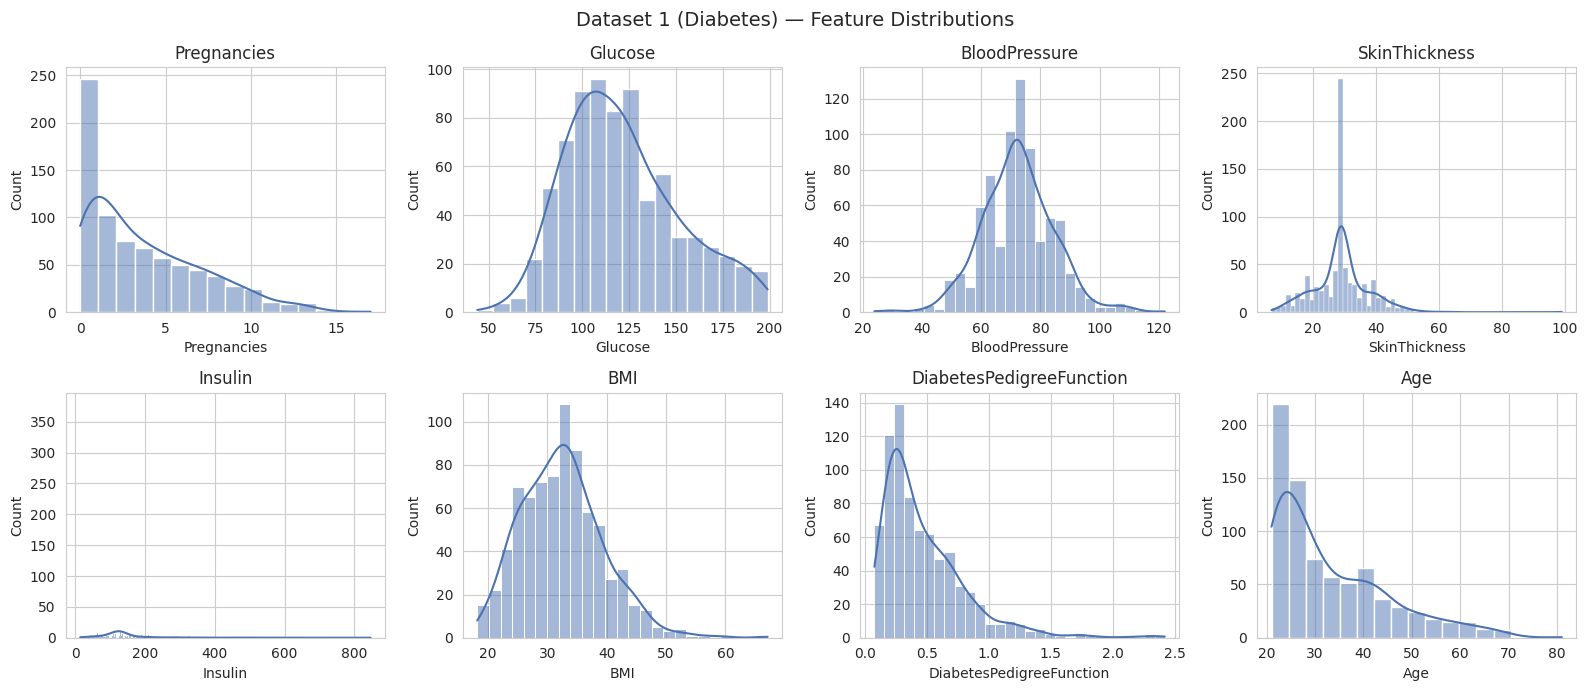

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), df1_clean.columns[:-1]):
    sns.histplot(df1_clean[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.suptitle("Dataset 1 (Diabetes) — Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

**Plot 2 — Correlation heatmap**

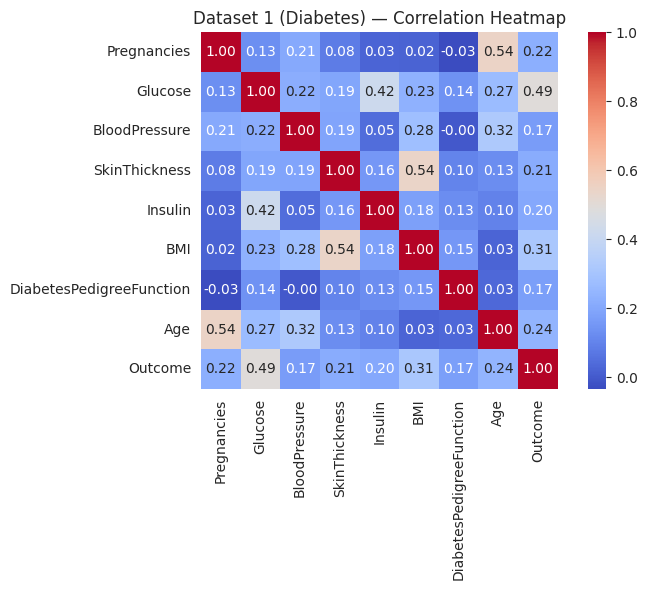

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df1_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Dataset 1 (Diabetes) — Correlation Heatmap")
plt.tight_layout()
plt.show()

**Plot 3 — Class balance**

/tmp/ipykernel_773/2739004466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Outcome", data=df1_clean, palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_773/2739004466.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])


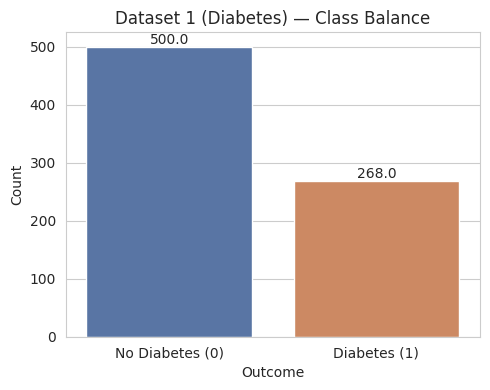

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="Outcome", data=df1_clean, palette=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
plt.title("Dataset 1 (Diabetes) — Class Balance")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(df1_clean["Outcome"].value_counts(normalize=True).round(3))

**EDA takeaway:** Glucose and BMI show the clearest visual separation between
classes and the strongest correlation with `Outcome`, so we'd expect them to be
important features later. The class split (~65% / 35%) is imbalanced but not
severe — worth keeping in mind when we evaluate with precision/recall rather
than accuracy alone.

## 1.4 Train / Test Split + Scaling

In [11]:
X1 = df1_clean.drop(columns=["Outcome"])
y1 = df1_clean["Outcome"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
)

# Logistic Regression is distance/gradient based, so features need to be on the
# same scale. Random Forest doesn't need this, but scaling does no harm to it,
# so we scale once and reuse for both models.
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

print("Train size:", X1_train.shape, " Test size:", X1_test.shape)

Train size: (614, 8)  Test size: (154, 8)


## 1.5 Model 1 — Logistic Regression

A simple, interpretable linear baseline. Good starting point for medical data
where explainability often matters as much as raw accuracy.

In [12]:
log_reg1 = LogisticRegression(random_state=RANDOM_STATE)
log_reg1.fit(X1_train_scaled, y1_train)
y1_pred_lr = log_reg1.predict(X1_test_scaled)

## 1.6 Model 2 — Random Forest

An ensemble of decision trees. Usually captures non-linear feature interactions
better than logistic regression, at some cost to interpretability.

In [13]:
rf1 = RandomForestClassifier(random_state=RANDOM_STATE)
rf1.fit(X1_train, y1_train)   # tree-based models don't need scaled features
y1_pred_rf = rf1.predict(X1_test)

## 1.7 Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix

**Plain-language note:** for a medical dataset, *recall* on the positive class
(catching actual diabetes cases) usually matters more than raw accuracy — a
missed diagnosis (false negative) is costlier than a false alarm.

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    """Print accuracy/precision/recall/F1 and return them as a dict for later comparison."""
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }
    print(f"--- {model_name} ---")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.3f}")
    print()
    return metrics

results_ds1 = []
results_ds1.append(evaluate_model(y1_test, y1_pred_lr, "Logistic Regression (Diabetes)"))
results_ds1.append(evaluate_model(y1_test, y1_pred_rf, "Random Forest (Diabetes)"))

pd.DataFrame(results_ds1).set_index("Model").round(3)

--- Logistic Regression (Diabetes) ---
Accuracy: 0.708
Precision: 0.600
Recall: 0.500
F1-Score: 0.545

--- Random Forest (Diabetes) ---
Accuracy: 0.779
Precision: 0.727
Recall: 0.593
F1-Score: 0.653



,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Diabetes),0.708,0.600,0.500,0.545
Random Forest (Diabetes),0.779,0.727,0.593,0.653


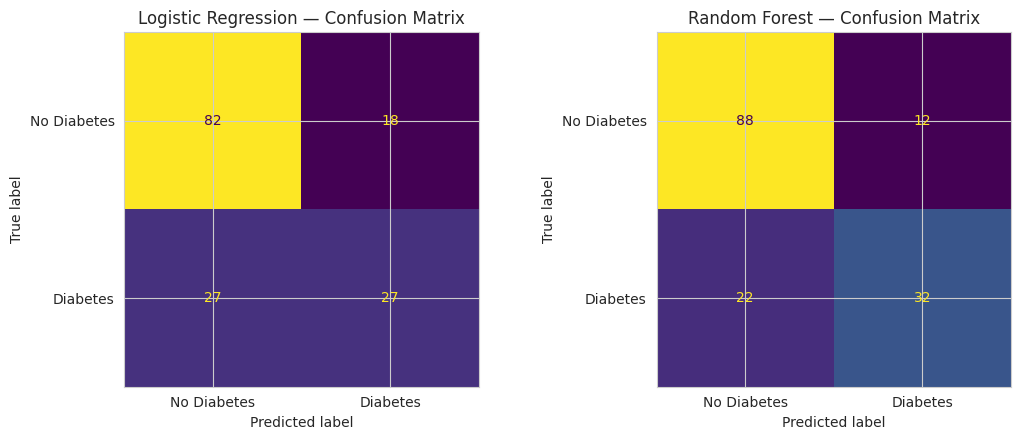

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred_lr),
                        display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression — Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred_rf),
                        display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.show()

## 1.8 Improving the Weaker Model — GridSearchCV

Whichever model scored lower on F1/Recall above, we tune it with `GridSearchCV`
to search over hyperparameters and pick the combination that generalizes best
under cross-validation, rather than guessing values by hand.

In [16]:
# Identify the weaker model automatically by comparing F1-scores computed above
weaker_ds1 = min(results_ds1, key=lambda r: r["F1-Score"])["Model"]
print("Weaker model on Dataset 1:", weaker_ds1)

Weaker model on Dataset 1: Logistic Regression (Diabetes)


In [17]:
if "Random Forest" in weaker_ds1:
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10],
        "class_weight": [None, "balanced"],
    }
    grid1 = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid, cv=5, scoring="f1", n_jobs=-1
    )
    grid1.fit(X1_train, y1_train)
    best_model1 = grid1.best_estimator_
    y1_pred_tuned = best_model1.predict(X1_test)
else:
    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"],
    }
    grid1 = GridSearchCV(
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        param_grid, cv=5, scoring="f1", n_jobs=-1
    )
    grid1.fit(X1_train_scaled, y1_train)
    best_model1 = grid1.best_estimator_
    y1_pred_tuned = best_model1.predict(X1_test_scaled)

print("Best params:", grid1.best_params_)
results_ds1.append(evaluate_model(y1_test, y1_pred_tuned, f"{weaker_ds1} (Tuned)"))
pd.DataFrame(results_ds1).set_index("Model").round(3)

Best params: {'C': 0.1, 'class_weight': 'balanced'}
--- Logistic Regression (Diabetes) (Tuned) ---
Accuracy: 0.708
Precision: 0.571
Recall: 0.667
F1-Score: 0.615



,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Diabetes),0.708,0.600,0.500,0.545
Random Forest (Diabetes),0.779,0.727,0.593,0.653
Logistic Regression (Diabetes) (Tuned),0.708,0.571,0.667,0.615


**Dataset 1 summary so far:** tuning improved the weaker model's F1-score by
searching hyperparameters + `class_weight="balanced"` under 5-fold
cross-validation, rather than relying on default settings. We'll compare all
three results side-by-side once Dataset 2 is done, in the final Comparative
Analysis Report.